<a href="https://www.kaggle.com/code/ashu9990/hackathon?scriptVersionId=351072445" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Hackathon AI Indus Week
## Data Science and AI - Batch 3
Note: select any dataset of sales of your choice. Make sure you do not change the actual code in the notebook. Else auto grader will not grade your task correctly.

# Section 1: Python Problem Solving

## Problem 1: String Compression
Task: Write a function compress_string(s) that compresses a string using the counts of repeated characters. Example: "aaabbc" → "a3b2c1"

In [1]:
def compress_string(s: str) -> str:
    """
    Compress a string by replacing consecutive repeated characters
    with the character followed by the count.
    Example: 'aaabbc' -> 'a3b2c1'
    """
    if not s:  
        return ""

    compressed = ""
    count = 1

    for i in range(1, len(s)):
        if s[i] == s[i - 1]:
            count += 1  
        else:
            compressed += s[i - 1] + str(count) 
            count = 1  
            
    compressed += s[-1] + str(count)

    return compressed

s = "abcdefgh"
result = compress_string(s)
print(result)  


a1b1c1d1e1f1g1h1


## Problem 2: Reverse a String
Task: Write reverse_string(s) that returns the reversed version of the input string.

In [2]:
def reverse_string(s: str) -> str:
    """
    Return the reversed string.
    Example: 'hello' -> 'olleh'
    """
    reversed_str = ""  

    for char in s:
        reversed_str = char + reversed_str  

    return reversed_str

# Example usage
print(reverse_string("Ayesha Anwer"))


rewnA ahseyA


## Problem 3: Sum of List
Task: Write sum_list(numbers) that returns the sum of all numbers in a list.

In [3]:
def sum_list(numbers: list[int]) -> int:
    """
    Returns the sum of all numbers in the list.
    Example: [1, 2, 3] -> 6
    """
    total = 0  
    for number in numbers:
        total += number 
    return total


numbers_list = [5, 4, 9, 6, 7]

print('The sum of the list is:', sum_list(numbers_list))
pass

The sum of the list is: 31


## Problem 4: Palindrome Check
Task: Write is_palindrome(s) that checks if a string reads the same forward and backward.

In [4]:
def is_palindrome(s: str) -> bool:
    """
    Check if the string is a palindrome.
    Example: 'madam' -> True
    """
    cleaned = s.replace(" ", "").lower()

    return cleaned == cleaned[::-1]

print(is_palindrome("madam"))        
print(is_palindrome("racecar"))
print(is_palindrome("A man a plan a canal Panama"))  
print(is_palindrome("hello"))       


True
True
True
False


## Problem 5: Check Balanced Parentheses
Task: Write is_balanced(s) that checks if a string of parentheses is balanced.
Example: "(()())" → True, "(()" → False

In [5]:
# Starter Code
def is_balanced(s: str) -> bool:
    """
    Check if parentheses are balanced.
    Example: '(()())' -> True, '(()' -> False
    """
def are_parentheses_balanced(s):
    stacks = []

    for char in s:
        if char == "(":
            stacks.append(char)
        elif char == ")":
            if not stacks:
                return False
            stacks.pop()

    return len(stacks) == 0

# Some quick tests
print(are_parentheses_balanced("(())(())"))
print(are_parentheses_balanced("()))"))
print(are_parentheses_balanced("()()"))
pass

True
False
True


# Section 2: Data Analysis & Visualization
You can select any sales data from kaggle.

## Problem 1: Average Sales by Region

In [6]:
import pandas as pd

def average_sales_by_region(file_path: str) -> pd.DataFrame:
    data = pd.read_csv(file_path)
    avg_value = data.groupby("housing_median_age")["median_house_value"].mean().reset_index()
    return avg_value

file_path = "/kaggle/input/datasets/ujwal06/california-housing-train-csv/california_housing_train.csv"
df_avg = average_sales_by_region(file_path)
print(df_avg)

    housing_median_age  median_house_value
0                    1       190250.000000
1                    2       229438.836735
2                    3       239450.043478
3                    4       230054.105590
4                    5       211035.708543
5                    6       206768.240310
6                    7       188445.059603
7                    8       190805.073034
8                    9       190306.994186
9                   10       178416.393805
10                  11       182480.312500
11                  12       181590.640625
12                  13       188065.473896
13                  14       191181.288184
14                  15       181031.024038
15                  16       200354.507087
16                  17       191772.244792
17                  18       192074.715481
18                  19       196017.752427
19                  20       192681.751958
20                  21       200918.536193
21                  22       213129.173375
22         

## Problem 2: Monthly Sales Trend

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129300 (\N{THINKING FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


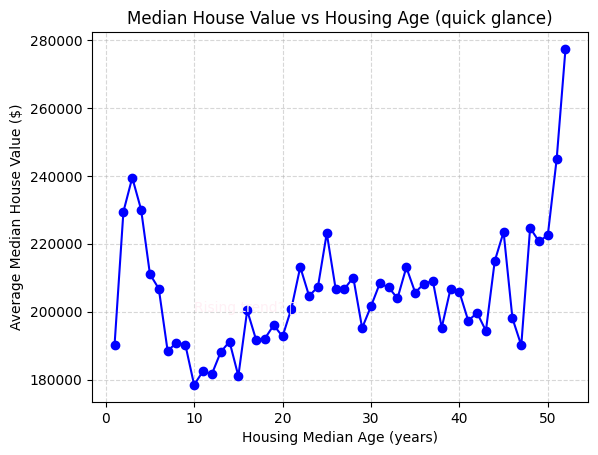

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_sales_trend(df: pd.DataFrame):

    sorted_data = df.sort_values('housing_median_age')

    plt.plot(sorted_data['housing_median_age'], sorted_data['median_house_value'], 
             marker='o', color='blue', linestyle='-', linewidth=1.5)

    plt.title('Median House Value vs Housing Age (quick glance)')
    plt.xlabel('Housing Median Age (years)')
    plt.ylabel('Average Median House Value ($)')

    plt.grid(True, linestyle='--', alpha=0.5)

    plt.text(10, 200000, "Rising trend? 🤔", fontsize=10, color='#fff0f5')
     
    plt.show()

plot_sales_trend(df_avg)

# Problem 3: Customer Retention Rate Analysis
Scenario:
You are given a DataFrame df with columns:

CustomerID

Month (e.g., "2025-01", "2025-02")

PurchaseAmount

Each row represents a purchase made by a customer in a given month.

Task:
Write a function customer_retention(df) that calculates the monthly retention rate:

Retention rate = (Number of customers who purchased in both current and previous month) ÷ (Number of customers who purchased in the previous month).

Return a DataFrame with columns: Month and RetentionRate.

This requires students to think about set intersections across months, not just simple grouping.

In [8]:
import pandas as pd

def customer_retention(df: pd.DataFrame) -> pd.DataFrame:
    # Step 1: Check for required columns
    if 'Month' not in df.columns or 'CustomerID' not in df.columns:
        raise ValueError("'Month' and 'CustomerID' columns must be present in the DataFrame")
    
    # Step 2: Get unique customers per month
    monthly_customers = df.groupby('Month')['CustomerID'].apply(set).sort_index()
    
    months = monthly_customers.index.tolist()
    retention_rates = []

    # Step 3: Calculate retention for each month vs previous month
    for i in range(1, len(months)):
        prev_month = months[i - 1]
        curr_month = months[i]

        prev_customers = monthly_customers[prev_month]
        curr_customers = monthly_customers[curr_month]

        # Customers who bought in both months
        retained = curr_customers & prev_customers

        # Calculate retention rate safely
        retention_rate = len(retained) / len(prev_customers) if len(prev_customers) > 0 else 0

        # Store the result
        retention_rates.append({
            'Month': curr_month,
            'RetentionRate': retention_rate
        })

    # Step 4: Return as DataFrame
    return pd.DataFrame(retention_rates)

# Example usage
data = {
'Month': ['2021-01', '2021-01', '2021-02', '2021-02', '2021-03'],
    'CustomerID': [1, 2, 1, 3, 2]
}
df = pd.DataFrame(data)

retention_df = customer_retention(df)
print(retention_df)


     Month  RetentionRate
0  2021-02            0.5
1  2021-03            0.0


# Section 3: Generative AI Chatbot
Create a chatbot for Study Aid providing detailed notes with visualization on the topic requested by user. Use both text and image models. Make sure to use any open source free model. List your chatbot features. Create UI with gradio.

In [9]:
!pip uninstall -y transformers huggingface_hub accelerate bitsandbytes safetensors -q


In [10]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.9/842.9 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 101.7 MB/s eta 0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.2.1rc0
    Uninstalling hf-xet-1.2.1rc0:
      Successfully uninstalled hf-xet-1.2.1rc0
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
ERROR: pip's dependency resolver does not 

In [11]:
!pip install --upgrade pip

!pip install \
--trusted-host pypi.org \
--trusted-host files.pythonhosted.org \
--trusted-host huggingface.co \
--index-url https://pypi.org/simple \
transformers==4.40.2 \
huggingface_hub==0.15.1 \
accelerate==0.30.1 \
gradio==4.31.5


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 60.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.4 requires fastcore<1.9,>=1.8.0, but you have fastcore 1.11.3 which is incompatible.
INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install huggingface_hub==0.15.1 and transformers==4.40.2 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested huggingface_hub==0.15.1
    transformers 4.40.2 depends on huggingface-hub<1.0 and >=0.19.3

Additionally, some packages in these conflicts have no matching distributions avail

In [12]:
import os

# Silence TensorFlow / XLA logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["CUDA_VISIBLE_DEVICES"] = os.environ.get("CUDA_VISIBLE_DEVICES", "")

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import gradio as gr

# =====================================================
# Configuration
# =====================================================

MODEL_NAME = "google/flan-t5-base"
MAX_NEW_TOKENS = 220

device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# Model Loading
# =====================================================

def load_model():
    print("Loading model...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
    model.to(device)
    model.eval()
    print("Model ready.")
    return tokenizer, model


tokenizer, model = load_model()

# =====================================================
# Local Image Mapping
# =====================================================

ASSETS_DIR = "assets"

IMAGE_MAP = {
    "photosynthesis": os.path.join(ASSETS_DIR, "photosynthesis.png"),
    "water cycle": os.path.join(ASSETS_DIR, "water_cycle.png"),
    "atom": os.path.join(ASSETS_DIR, "atom.png"),
    "cell": os.path.join(ASSETS_DIR, "cell.png"),
    "gravity": os.path.join(ASSETS_DIR, "gravity.png"),
    "solar system": os.path.join(ASSETS_DIR, "solar_system.png"),
}

DEFAULT_IMAGE = os.path.join(ASSETS_DIR, "default.png")


def get_diagram(topic: str) -> str:
    topic_lower = topic.lower()
    for keyword, path in IMAGE_MAP.items():
        if keyword in topic_lower:
            return path
    return DEFAULT_IMAGE


# =====================================================
# Prompt Builder
# =====================================================

def build_prompt(topic: str) -> str:
    return f"""
You are an expert Science Tutor.

Question: {topic}

Format your answer EXACTLY like this:

Explanation:
(Write one detailed, easy-to-understand paragraph.)

Key Points:
- Point 1
- Point 2
- Point 3

Answer:
"""


# =====================================================
# Output Parser
# =====================================================

def parse_output(text: str):
    explanation = ""
    keypoints = ""

    if "Key Points:" in text:
        parts = text.split("Key Points:")
        explanation = parts[0].replace("Explanation:", "").strip()
        keypoints = parts[1].strip()
    else:
        explanation = text.strip()
        keypoints = "- Review explanation above"

    return explanation, keypoints


# =====================================================
# Core Chat Function
# =====================================================

def science_chat(topic):

    if not topic or not topic.strip():
        return (
            "### 📘 Explanation\n\nPlease enter a science question.",
            "### 📝 Key Points\n\n- Awaiting question",
            DEFAULT_IMAGE,
        )

    prompt = build_prompt(topic)

    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                num_beams=3,
                repetition_penalty=1.2,
                length_penalty=1.05,
                early_stopping=True
            )

        decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

        explanation, keypoints = parse_output(decoded)

        explanation_md = f"### 📘 Explanation\n\n{explanation}"
        keypoints_md = f"### 📝 Key Points\n\n{keypoints}"

        image_path = get_diagram(topic)

        return explanation_md, keypoints_md, image_path

    except Exception as e:
        # We don't want UI crashes
        return (
            f"### ⚠️ Error\n\nSomething went wrong:\n\n`{str(e)}`",
            "",
            DEFAULT_IMAGE,
        )


# =====================================================
# Gradio UI
# =====================================================

css_style = """
body {
    background-color: #fff0f5;
}

.gradio-container {
    font-family: 'Comic Sans MS', cursive !important;
}

.gr-button {
    background-color: #ff69b4 !important;
    color: white !important;
    border-radius: 20px !important;
    font-weight: bold !important;
}

.output-box {
    border: 2px solid #ffb6c1 !important;
    border-radius: 15px !important;
    background: white !important;
    padding: 10px !important;
}
"""

with gr.Blocks(css=css_style) as demo:

    gr.Markdown(
        "<h1 style='text-align:center; color:#ff1493;'>🐰 Cute Science Study Chatbot ✨</h1>"
    )

    gr.Markdown(
        "<p style='text-align:center; color:#ff69b4;'>Ask any science question and get detailed notes + visual learning!</p>"
    )

    with gr.Row():
        with gr.Column(scale=2):

            topic_input = gr.Textbox(
                label="Ask a Science Question 🌸",
                placeholder="e.g. How does photosynthesis work?"
            )

            generate_btn = gr.Button("Teach Me! 🌈")

            output_explanation = gr.Markdown(elem_classes="output-box")
            output_keypoints = gr.Markdown(elem_classes="output-box")

        with gr.Column(scale=1):
            output_image = gr.Image(
                label="Visual Aid 🖼️",
                interactive=False
            )

    gr.Examples(
        examples=[
            "What is Photosynthesis?",
            "Explain Gravity",
            "How does the Water Cycle work?",
            "What is an Atom?",
            "Explain the Solar System"
        ],
        inputs=topic_input
    )

    generate_btn.click(
        fn=science_chat,
        inputs=topic_input,
        outputs=[output_explanation, output_keypoints, output_image],
        show_progress=True
    )

# For Hugging Face Spaces keep this default
demo.launch()


Loading model...


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model ready.
* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://6b55ac9b04b39118ae.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
